### K-means++ Algorithm

Four separate Gaussian clusters are generated with different means and covariances to simulate different groupings in the data.

https://www.geeksforgeeks.org/machine-learning/ml-k-means-algorithm/

In [1]:
import matplotlib.pyplot as plt
import numpy as np

mean_01 = np.array([0.0, 0.0])
cov_01 = np.array([[1, 0.3], [0.3, 1]])
dist_01 = np.random.multivariate_normal(mean_01, cov_01, 100)

mean_02 = np.array([6.0, 7.0])
cov_02 = np.array([[1.5, 0.3], [0.3, 1]])
dist_02 = np.random.multivariate_normal(mean_02, cov_02, 100)

mean_03 = np.array([7.0, -5.0])
dist_03 = np.random.multivariate_normal(mean_03, cov_01, 100)

mean_04 = np.array([2.0, -7.0])
cov_04 = np.array([[1.2, 0.5], [0.5, 1.3]])
dist_04 = np.random.multivariate_normal(mean_04, cov_01, 100)

data = np.vstack((dist_01, dist_02, dist_03, dist_04))
np.random.shuffle(data)

In [2]:
def plot(data, centroids):
    plt.scatter(data[:, 0], data[:, 1], marker='.', color='gray', label='Data Points')
    if centroids.shape[0] > 1:
        plt.scatter(centroids[:-1, 0], centroids[:-1, 1], color='black', label='Selected Centroids')
    plt.scatter(centroids[-1, 0], centroids[-1, 1], color='red', label='Next Centroid')
    plt.title(f'Select {centroids.shape[0]}th Centroid')
    plt.legend()
    plt.xlim(-5, 12)
    plt.ylim(-10, 15)
    plt.show()

In [3]:
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

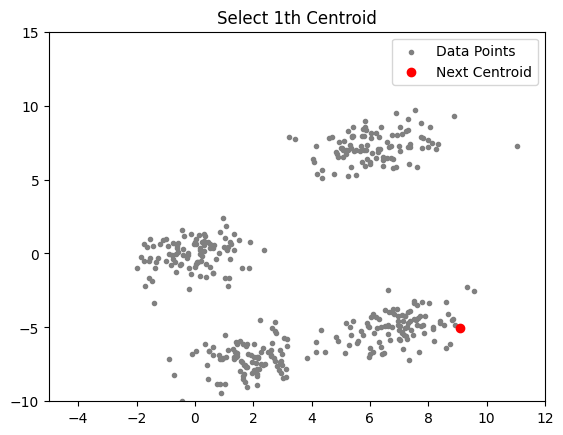

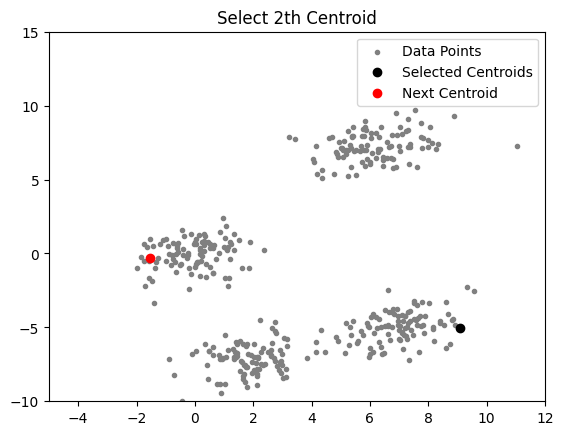

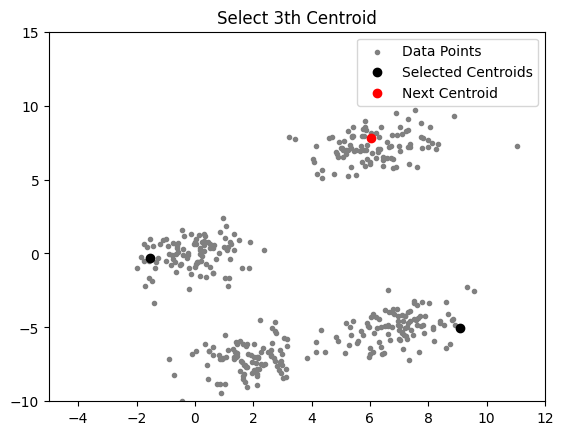

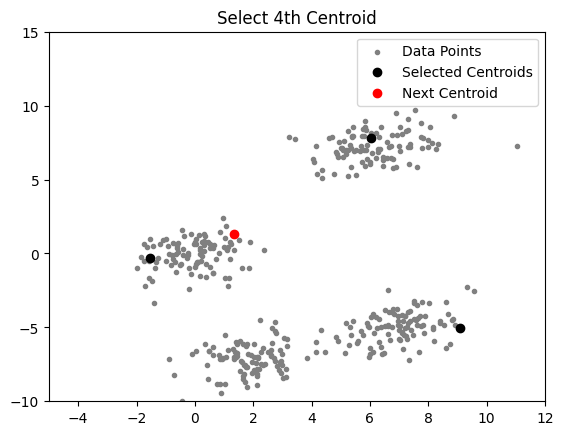

In [4]:
def initialize(data, k):
    centroids = []
    centroids.append(data[np.random.randint(data.shape[0])])
    plot(data, np.array(centroids))

    for _ in range(k - 1):
        distances = []
        for point in data:
            min_dist = min([distance(point, c) for c in centroids])
            distances.append(min_dist)

        distances = np.array(distances)
        probabilities = distances ** 2 / np.sum(distances ** 2)

        next_centroid = next_centroid = data[np.random.choice(len(data), p=probabilities)]
        centroids.append(next_centroid)
        plot(data, np.array(centroids))

    return np.array(centroids)


# Run initialization
centroids = initialize(data, k=4)